# TS3: Análisis de Fourier: FFT, desparramo, interpolación y ventaneo

En esta tarea se analiza el efecto de desparramo espectral al calcular la DFT de una señal senoidal.

Se trabaja con una senoidal de frecuencia:

$$
f_0 = k_0 \frac{f_s}{N} = k_0 \Delta f
$$

donde:

$$
\Delta f = \frac{f_s}{N}
$$

La señal se genera con potencia normalizada, es decir con varianza o potencia unitaria.

Se analizan tres casos:

- $k_0 = N/4$
- $k_0 = N/4 + 0.25$
- $k_0 = N/4 + 0.5$

Luego se repite el experimento utilizando zero padding, agregando ceros al final de la señal para observar con mayor detalle el espectro.

In [5]:
# Módulos externos
import matplotlib.pyplot as plt
import numpy as np

## Definición de parámetros

Se define una frecuencia de muestreo de $f_s = 1000$ Hz y una cantidad de muestras $N = 1000$.

Por lo tanto, la resolución espectral resulta:

$$
\Delta f = \frac{f_s}{N} = 1 \text{ Hz}
$$

El tiempo entre muestras es:

$$
T_s = \frac{1}{f_s}
$$

Como se pide que la senoidal tenga potencia unitaria, se utiliza una amplitud pico:

$$
A = \sqrt{2}
$$

ya que para una senoidal pura de valor medio nulo se cumple:

$$
P = \frac{A^2}{2}
$$

Entonces, si $A = \sqrt{2}$, la potencia resulta $P = 1$.

In [6]:
fs = 1000
N = 1000
df = fs/N
ts = 1/fs
dc = 0

f0 = N/4 * df
f01 = (N/4 + 1/4)* df
f02 = (N/4 + 1/2)* df
vmax = np.sqrt(2)

tt = np.arange(N) * ts

fx = dc + vmax * np.sin(2*np.pi*f0*tt)
fx1 = dc + vmax * np.sin(2*np.pi*f01*tt)
fx2 = dc + vmax * np.sin(2*np.pi*f02*tt)

frec = np.arange(N) * fs / N

## Frecuencias analizadas

Las tres senoidales tienen frecuencias muy cercanas entre sí:

$$
f_0 = \frac{N}{4}\Delta f
$$

$$
f_{01} = \left(\frac{N}{4}+0.25\right)\Delta f
$$

$$
f_{02} = \left(\frac{N}{4}+0.5\right)\Delta f
$$

Como en este caso $\Delta f = 1$ Hz, las frecuencias son aproximadamente 250 Hz, 250.25 Hz y 250.5 Hz.

Aunque en frecuencia absoluta la diferencia entre ellas es pequeña, su representación mediante la DFT puede cambiar mucho, porque la DFT evalúa el espectro únicamente en una grilla discreta de frecuencias.

In [7]:
print("fs =", fs, "Hz")
print("N =", N)
print("df =", df, "Hz")
print("ts =", ts, "s")
print("f0 =", f0, "Hz")
print("f01 =", f01, "Hz")
print("f02 =", f02, "Hz")

fs = 1000 Hz
N = 1000
df = 1.0 Hz
ts = 0.001 s
f0 = 250.0 Hz
f01 = 250.25 Hz
f02 = 250.5 Hz


## a) FFT para $k_0 = N/4$

En este primer caso, la frecuencia de la senoidal coincide exactamente con un múltiplo entero de la resolución espectral $\Delta f$.

Esto significa que la frecuencia de la señal cae exactamente sobre un bin de la DFT. Por lo tanto, la energía de la senoidal queda concentrada en ese bin de frecuencia positiva y en su correspondiente bin de frecuencia negativa.

Al representar solamente entre 0 y $f_s/2$, se observa un único pico concentrado alrededor de 250 Hz.

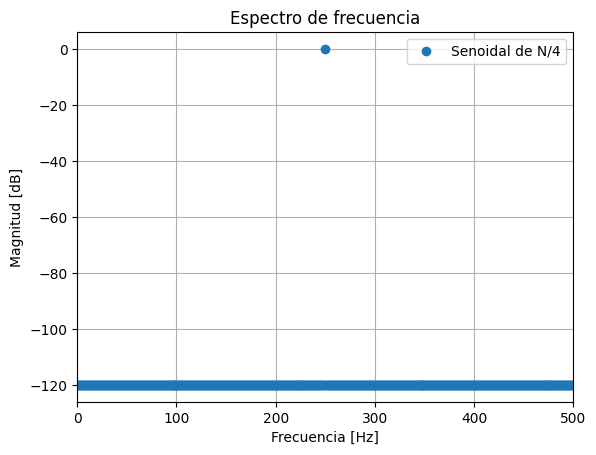

In [8]:
#%%FFT f0 = N/4
eps = 1e-12

FX = np.fft.fft(fx) / N
FX_mod = np.abs(FX)**2
FX_db = 10 * np.log10(FX_mod*2 + eps)

plt.figure()
plt.title('Espectro de frecuencia')
plt.plot(frec, FX_db, marker='o', linestyle='None', label = 'Senoidal de N/4')
plt.xlim(0, fs/2)
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Magnitud [dB]')
plt.grid()
plt.legend()
plt.show()

## a) FFT para $k_0 = N/4 + 0.25$

En este segundo caso, la frecuencia de la senoidal ya no coincide exactamente con un bin de la DFT.

Aunque la diferencia respecto del caso anterior es de solo 0.25 Hz, la frecuencia queda desintonizada respecto de la grilla espectral. Como consecuencia, la energía ya no queda concentrada en un único bin, sino que se reparte entre varios bins vecinos.

Este efecto se conoce como **desparramo espectral** o *spectral leakage*.

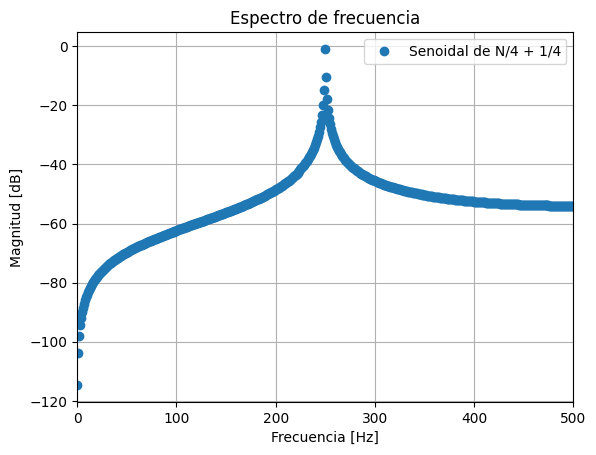

In [9]:
#%%FFT f0 = N/4 + 1/4

FX1 = np.fft.fft(fx1) / N
FX1_mod = np.abs(FX1)**2
FX1_db = 10 * np.log10(FX1_mod*2 + eps)

plt.figure()
plt.title('Espectro de frecuencia')
plt.plot(frec, FX1_db, marker='o', linestyle='None', label = 'Senoidal de N/4 + 1/4')
plt.xlim(0, fs/2)
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Magnitud [dB]')
plt.grid()
plt.legend()
plt.show()

## a) FFT para $k_0 = N/4 + 0.5$

En este tercer caso, la frecuencia de la senoidal queda ubicada a mitad de camino entre dos bins de la DFT.

Este caso muestra con más claridad el desparramo espectral, ya que la energía de la señal no coincide exactamente con ninguno de los bins disponibles. Por eso, la potencia se distribuye entre varios bins y el pico máximo observado puede ser menor que en el caso perfectamente sintonizado.

La señal no perdió potencia: lo que cambió es la forma en que esa potencia se reparte en la representación espectral discreta.

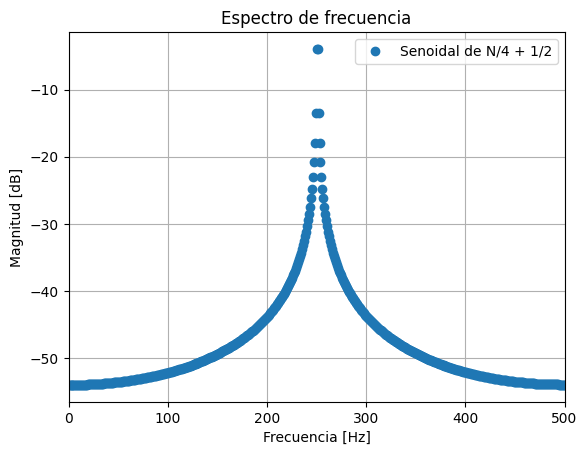

In [10]:
#%%FFT f0 = N/4 + 1/2

FX2 = np.fft.fft(fx2) / N
FX2_mod = np.abs(FX2)**2
FX2_db = 10 * np.log10(FX2_mod*2 + eps)

plt.figure()
plt.title('Espectro de frecuencia')
plt.plot(frec, FX2_db, marker='o', linestyle='None', label = 'Senoidal de N/4 + 1/2')
plt.xlim(0, fs/2)
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Magnitud [dB]')
plt.grid()
plt.legend()
plt.show()

## Discusión del punto a)

Se observa que las tres señales tienen frecuencias muy cercanas, pero sus espectros se ven diferentes.

La razón es que la DFT evalúa el contenido espectral solamente en frecuencias discretas separadas por $\Delta f$. Cuando la frecuencia de la senoidal coincide exactamente con un bin, como en el caso $k_0 = N/4$, la energía queda concentrada en ese bin.

En cambio, cuando la frecuencia no es un múltiplo entero de $\Delta f$, la DFT no tiene un bin ubicado exactamente en la frecuencia de la señal. Por eso, la energía aparece repartida entre varios bins. Este fenómeno es el desparramo espectral.

## c) Zero padding

A continuación se repite el experimento usando zero padding.

El zero padding consiste en agregar ceros al final de la señal antes de calcular la FFT. En este caso, la consigna pide agregar un vector de $9N$ ceros al final.

Por lo tanto, la longitud total usada para la FFT pasa de $N$ a:

$$
N_z = N + 9N = 10N
$$

Esto genera una grilla de frecuencias más densa. Sin embargo, es importante aclarar que el zero padding no agrega información nueva a la señal ni elimina el desparramo espectral. Lo que hace es interpolar la visualización del espectro.

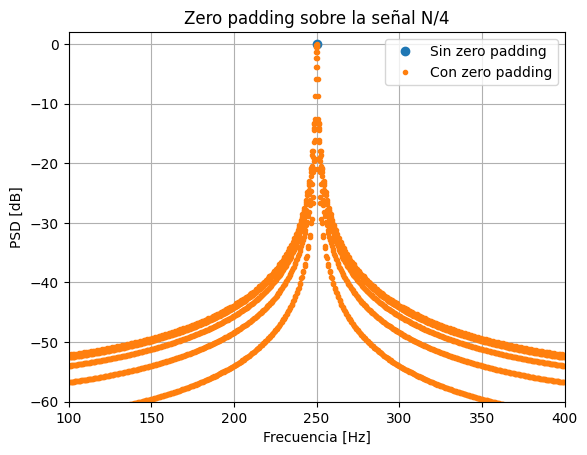

In [11]:
#%% Ventana rectangular - zero padding
# Frecuencia = N/4

N0 = N*10
frecz = np.arange(N0) * fs / N0

zz = np.zeros(9*N)
fxzz = np.concatenate((fx,zz), axis = None)
fxzz_sinc_FFT = np.fft.fft(fxzz) / N
fxzz_sinc_mod = np.abs(fxzz_sinc_FFT)**2
fxzz_sinc_db = 10 * np.log10(fxzz_sinc_mod *2 + eps)

plt.figure()
plt.title('Zero padding sobre la señal N/4')

plt.plot(frec, FX_db, 'o', linestyle='None', label='Sin zero padding')
plt.plot(frecz, fxzz_sinc_db, '.', linestyle='None', label='Con zero padding')

plt.xlim([100, 400])
plt.ylim([-60, 2])
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('PSD [dB]')
plt.grid()
plt.legend()
plt.show()

## Zero padding para $k_0 = N/4$

En este caso, la señal original estaba perfectamente sintonizada con un bin de la DFT.

Al aplicar zero padding, se observa el espectro con más puntos. Esto permite ver con más detalle la forma asociada a la ventana rectangular de observación.

Sin embargo, el zero padding no modifica la señal original. Los puntos de la DFT original siguen estando contenidos dentro de la nueva representación más densa.

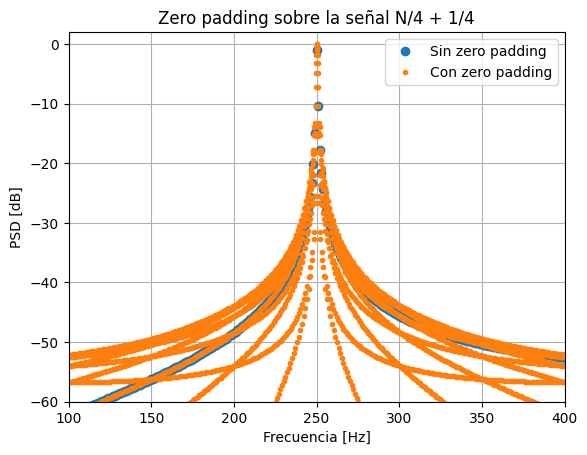

In [12]:
#%% Frecuencia = N/4 + 1/4

fxzz1 = np.concatenate((fx1,zz), axis = None)
fxzz1_sinc_FFT = np.fft.fft(fxzz1) / N
fxzz1_sinc_mod = np.abs(fxzz1_sinc_FFT)**2
fxzz1_sinc_db = 10 * np.log10(fxzz1_sinc_mod *2 + eps)

plt.figure()
plt.title('Zero padding sobre la señal N/4 + 1/4')

plt.plot(frec, FX1_db, 'o', linestyle='None', label='Sin zero padding')
plt.plot(frecz, fxzz1_sinc_db, '.', linestyle='None', label='Con zero padding')

plt.xlim([100, 400])
plt.ylim([-60, 2])
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('PSD [dB]')
plt.grid()
plt.legend()
plt.show()

## Zero padding para $k_0 = N/4 + 0.25$

Para la señal con $k_0 = N/4 + 0.25$, la frecuencia no coincide con un bin de la DFT original.

Al aplicar zero padding, se obtiene una representación espectral con mayor cantidad de muestras en frecuencia. Esto permite observar mejor la ubicación del máximo y la forma del lóbulo principal.

De todos modos, el desparramo espectral sigue presente. El zero padding no corrige el leakage, sino que permite visualizarlo con mayor detalle.

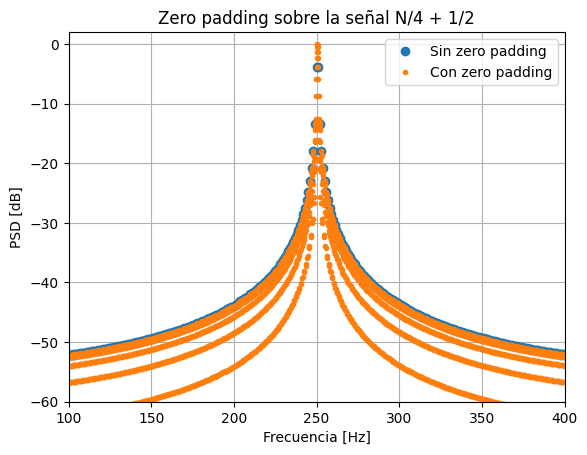

In [13]:
#%% Frecuencia = N/4 + 1/2

fxzz2 = np.concatenate((fx2,zz), axis = None)
fxzz2_sinc_FFT = np.fft.fft(fxzz2) / N
fxzz2_sinc_mod = np.abs(fxzz2_sinc_FFT)**2
fxzz2_sinc_db = 10 * np.log10(fxzz2_sinc_mod *2 + eps)

plt.figure()
plt.title('Zero padding sobre la señal N/4 + 1/2')

plt.plot(frec, FX2_db, 'o', linestyle='None', label='Sin zero padding')
plt.plot(frecz, fxzz2_sinc_db, '.', linestyle='None', label='Con zero padding')

plt.xlim([100, 400])
plt.ylim([-60, 2])
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('PSD [dB]')
plt.grid()
plt.legend()
plt.show()

## Zero padding para $k_0 = N/4 + 0.5$

En este caso, la frecuencia queda justo entre dos bins de la DFT original.

Sin zero padding, la energía parece repartirse entre los bins cercanos. Con zero padding, la grilla de frecuencia es más fina y se puede ver mejor que el máximo se ubica alrededor de la frecuencia real de la señal.

Esto confirma que el zero padding mejora la visualización del espectro, pero no aumenta la información real disponible ni elimina el desparramo espectral.

## Discusión del punto c)

Al aplicar zero padding, la cantidad de puntos de la FFT aumenta. Como consecuencia, la separación entre muestras del espectro disminuye y se obtiene una visualización más detallada.

Sin embargo, el zero padding no aumenta la resolución real del experimento. La resolución física sigue estando determinada por la duración temporal original de la señal.

Tampoco elimina el desparramo espectral. Si la señal no coincide con un bin de la DFT original, el leakage sigue existiendo. Lo que cambia es que ahora se puede observar mejor la forma del espectro y la ubicación del máximo.

Por este motivo, puede decirse que el zero padding interpola el espectro, pero no agrega información nueva.

## b) Verificación de potencia

Se verifica la potencia de las tres señales en el dominio temporal mediante:

$$
P_x = \frac{1}{N}\sum_{n=0}^{N-1} x^2[n]
$$

Como las senoidales fueron generadas con amplitud $\sqrt{2}$ y valor medio nulo, la potencia esperada es aproximadamente 1.

También se verifica la potencia luego de aplicar zero padding. En ese caso, se divide por $N$ y no por $10N$, porque los ceros agregados no forman parte de la señal original, sino que se agregan solamente para interpolar el espectro.

In [14]:
#%% Potencia

P_fx = np.mean(fx**2)
P_fx1 = np.mean(fx1**2)
P_fx2 = np.mean(fx2**2)

P_fxzz = np.sum(fxzz**2) / N
P_fxzz1 = np.sum(fxzz1**2) / N
P_fxzz2 = np.sum(fxzz2**2) / N

print("Potencia fx =", P_fx)
print("Potencia fx1 =", P_fx1)
print("Potencia fx2 =", P_fx2)

print("Potencia fxzz escalada por N =", P_fxzz)
print("Potencia fxzz1 escalada por N =", P_fxzz1)
print("Potencia fxzz2 escalada por N =", P_fxzz2)

Potencia fx = 1.0000000000000002
Potencia fx1 = 0.9989999999999996
Potencia fx2 = 1.0000000000000004
Potencia fxzz escalada por N = 1.0000000000000002
Potencia fxzz1 escalada por N = 0.9989999999999996
Potencia fxzz2 escalada por N = 1.0000000000000004


## Discusión del punto b)

Los resultados muestran que las tres señales tienen potencia aproximadamente unitaria. Esto es coherente con la amplitud elegida, ya que para una senoidal de amplitud pico $\sqrt{2}$ y valor medio nulo, la potencia media vale 1.

Por lo tanto, las diferencias observadas en los espectros no se deben a diferencias de potencia entre las señales.

La razón por la cual una señal senoidal puede tener un espectro tan diferente respecto de otra de muy pocos Hertz de diferencia es que la DFT analiza la señal sobre una grilla discreta de frecuencias. Si la frecuencia coincide exactamente con esa grilla, la energía se concentra en un bin. Si no coincide, la energía se distribuye entre varios bins.

Entonces, el cambio visual en el espectro se debe a la desintonía respecto de $\Delta f$, no a una variación significativa de la señal en el dominio temporal.

## Conclusión

En esta tarea se analizó el efecto de desparramo espectral al calcular la DFT de señales senoidales.

Se observó que, cuando la frecuencia de la senoidal coincide exactamente con un múltiplo entero de la resolución espectral $\Delta f$, la energía queda concentrada en un bin de la DFT. Esto ocurrió para el caso $k_0 = N/4$.

En cambio, al introducir una pequeña desintonía, como en los casos $k_0 = N/4 + 0.25$ y $k_0 = N/4 + 0.5$, la frecuencia de la señal deja de coincidir con la grilla de la DFT. Como consecuencia, la energía se reparte entre varios bins, produciendo desparramo espectral.

También se verificó que las señales mantienen potencia aproximadamente unitaria. Por lo tanto, las diferencias observadas en los espectros no se deben a cambios de potencia, sino a la forma en que la DFT representa la energía según la relación entre la frecuencia de la señal y los bins disponibles.

Finalmente, se aplicó zero padding agregando $9N$ ceros al final de cada señal. Esta técnica permitió observar el espectro con una grilla de frecuencias más densa. Sin embargo, no eliminó el leakage ni agregó información nueva a la señal. Su efecto principal fue interpolar la visualización del espectro y permitir observar con mayor detalle la forma de los lóbulos.